In [1]:
!pip install diffusers transformers accelerate torch

In [3]:
# Importing Required libraries
import os
import torch
from diffusers import StableDiffusionPipeline
from matplotlib import pyplot as plt

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


##--- CONFIGURATION ---

In [4]:
# 1. Select Domain & Model
model_id = "runwayml/stable-diffusion-v1-5"
output_folder = "synthetic_dataset"

# 2. Provide Input Prompts (At least 5)
prompts = [
    "A futuristic city with flying cars at sunset, cyberpunk style",
    "A realistic photo of a golden retriever playing in the snow",
    "An oil painting of a cottage by a river, impressionist style",
    "A robot playing chess against a human, high detail",
    "A bowl of exotic alien fruit glowing in the dark"
]

# -

## --- IMPLEMENTATION ---

In [5]:
def generate_synthetic_data():
    # Create output directory if it doesn't exist
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        print(f"Created folder: {output_folder}")

    # Load the Pre-trained Generative Model
    print("Loading Stable Diffusion model... (this may take a minute)")
    pipe = StableDiffusionPipeline.from_pretrained(
        model_id,
        torch_dtype=torch.float16
    )

    # Move model to GPU for faster generation
    if torch.cuda.is_available():
        pipe = pipe.to("cuda")
        print("Model loaded on GPU.")
    else:
        print("Warning: GPU not found. Generation will be slow.")

    # 4. Generate Synthetic Data
    print(f"\nGenerating {len(prompts)} images...")
    generated_images = []

    for i, prompt in enumerate(prompts):
        print(f"Generating sample {i+1}: '{prompt}'")

        # Generate image
        image = pipe(prompt).images[0]

        # 5. Save generated output
        file_name = f"{output_folder}/sample_{i+1}.png"
        image.save(file_name)
        generated_images.append(image)
        print(f"Saved to {file_name}")

    return generated_images

## --- EXECUTION & DISPLAY ---

Created folder: synthetic_dataset
Loading Stable Diffusion model... (this may take a minute)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Saved to synthetic_dataset/sample_3.png
Generating sample 4: 'A robot playing chess against a human, high detail'


  0%|          | 0/50 [00:00<?, ?it/s]

Saved to synthetic_dataset/sample_4.png
Generating sample 5: 'A bowl of exotic alien fruit glowing in the dark'


  0%|          | 0/50 [00:00<?, ?it/s]

Saved to synthetic_dataset/sample_5.png

--- Displaying Sample Outputs ---


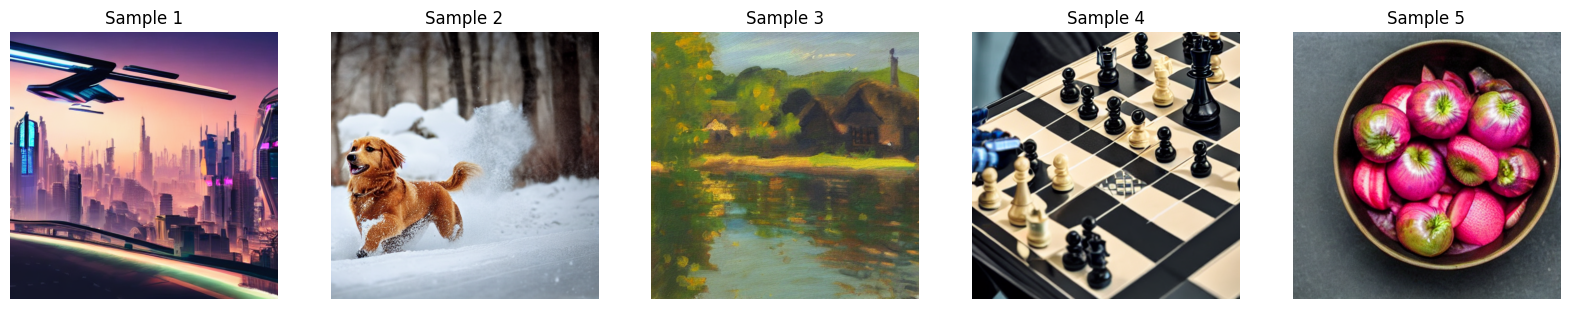

In [6]:
# Run the generation
images = generate_synthetic_data()

# 6. Display Sample Outputs
print("\n--- Displaying Sample Outputs ---")
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
for i, (img, prompt) in enumerate(zip(images, prompts)):
    axs[i].imshow(img)
    axs[i].axis('off')
    axs[i].set_title(f"Sample {i+1}")
plt.show()

In [8]:
# Testing

import os
import torch
from diffusers import StableDiffusionPipeline

# --- 1. CONFIGURATION ---
# Define the root dataset folder
dataset_root = "Cat_Species_Dataset"

# List of species (Class Labels)
# You can add more species to this list as needed.
cat_species_list = [
    "Lion",
    "Tiger",
    "Cheetah",
    "Persian Cat",
    "Siamese Cat",
]

# Number of images per species
images_per_class = 10

# --- 2. LOAD MODEL ---
print("Loading Stable Diffusion model...")
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

if torch.cuda.is_available():
    pipe = pipe.to("cuda")
    print("Model loaded on GPU.")
else:
    print("Warning: GPU not found. This will be very slow.")

# --- 3. GENERATION LOOP ---
def create_cat_dataset():
    total_images = len(cat_species_list) * images_per_class
    print(f"Starting generation of {total_images} images across {len(cat_species_list)} classes.\n")

    for species in cat_species_list:
        # Create the sub-directory for the specific species (Label)
        species_folder = os.path.join(dataset_root, species)
        os.makedirs(species_folder, exist_ok=True)

        print(f"--- Processing Class: {species} ---")

        for i in range(images_per_class):
            # Dynamic Prompting: We insert the species name into the prompt
            prompt = f"A realistic, high-resolution photo of a {species} in its natural habitat, highly detailed, 8k"

            # Generate image
            # logical_step: Generate 1 image at a time
            image = pipe(prompt).images[0]

            # Save image with unique name inside the species folder
            file_name = f"{species}_{i+1}.png"
            save_path = os.path.join(species_folder, file_name)
            image.save(save_path)

            print(f"  [Saved] {file_name}")

    print(f"\nSuccess! Dataset generated at: {dataset_root}")

# --- 4. VERIFY DATASET STRUCTURE ---
def verify_dataset():
    print("\n--- Verifying Dataset Structure ---")
    if not os.path.exists(dataset_root):
        print("Dataset folder not found!")
        return

    # Walk through the directory and count files
    for root, dirs, files in os.walk(dataset_root):
        if root != dataset_root: # Ignore the root folder itself
            label = os.path.basename(root)
            count = len([f for f in files if f.endswith('.png')])
            print(f"Label: '{label}' \t| Images Found: {count}")

# Run the functions
create_cat_dataset()
verify_dataset()

Loading Stable Diffusion model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model loaded on GPU.
Starting generation of 50 images across 5 classes.

--- Processing Class: Lion ---


  0%|          | 0/50 [00:00<?, ?it/s]

  [Saved] Lion_1.png


...

  [Saved] Siamese Cat_8.png


  0%|          | 0/50 [00:00<?, ?it/s]

  [Saved] Siamese Cat_9.png


  0%|          | 0/50 [00:00<?, ?it/s]

  [Saved] Siamese Cat_10.png

Success! Dataset generated at: Cat_Species_Dataset

--- Verifying Dataset Structure ---
Label: 'Tiger' 	| Images Found: 10
Label: 'Persian Cat' 	| Images Found: 10
Label: 'Lion' 	| Images Found: 10
Label: 'Siamese Cat' 	| Images Found: 10
Label: 'Cheetah' 	| Images Found: 10


In [10]:
import os
import torch
from diffusers import StableDiffusionPipeline

# --- 1. CONFIGURATION ---
dataset_root = "Cat_Species_Dataset"

# The complete list of ~41 recognized species in the Felidae family
# Grouped by lineage for organization
cat_species_list = [
    # --- Panthera Lineage (The Big Cats) ---
    "Lion", "Tiger", "Leopard", "Jaguar", "Snow Leopard",

    # --- Clouded Leopard Lineage ---
    "Clouded Leopard", "Sunda Clouded Leopard",

    # --- Puma Lineage ---
    "Cheetah", "Puma", "Jaguarundi",

    # --- Lynx Lineage ---
    "Eurasian Lynx", "Canada Lynx", "Iberian Lynx", "Bobcat",

    # --- Caracal Lineage ---
    "Caracal", "Serval", "African Golden Cat",

    # --- Ocelot Lineage ---
    "Ocelot", "Margay", "Andean Mountain Cat", "Pampas Cat",
    "Geoffroy's Cat", "Kodkod", "Oncilla",

    # --- Bay Cat Lineage ---
    "Asian Golden Cat", "Bornean Bay Cat", "Marbled Cat",

    # --- Leopard Cat Lineage ---
    "Leopard Cat", "Sunda Leopard Cat", "Fishing Cat",
    "Flat-headed Cat", "Rusty-spotted Cat", "Pallas's Cat",

    # --- Domestic Cat Lineage ---
    "Domestic Cat", "European Wildcat", "African Wildcat",
    "Chinese Mountain Cat", "Jungle Cat", "Sand Cat", "Black-footed Cat"
]

images_per_class = 10

# --- 2. LOAD MODEL ---
print("Loading Stable Diffusion model...")
model_id = "runwayml/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    torch_dtype=torch.float16
)

if torch.cuda.is_available():
    pipe = pipe.to("cuda")
    print("Model loaded on GPU.")
else:
    print("Warning: GPU not found. This will take hours.")

# --- 3. GENERATION LOOP ---
def create_full_cat_dataset():
    total_images = len(cat_species_list) * images_per_class
    print(f"Starting generation of {total_images} images across {len(cat_species_list)} species.\n")

    for species in cat_species_list:
        # Create folder for the species (Label)
        species_folder = os.path.join(dataset_root, species)
        os.makedirs(species_folder, exist_ok=True)

        print(f"--- Processing Species: {species} ---")

        for i in range(images_per_class):
            # Prompt engineering: specifically asking for 'wild cat' features for wild species
            # and 'photo' style to ensure consistency.
            if species == "Domestic Cat":
                prompt = f"A realistic photo of a Domestic Cat, high detailed, 8k"
            else:
                prompt = f"A realistic nature documentary photo of a {species} wild cat in its natural habitat, high detailed, 8k, national geographic style"

            try:
                # Generate
                image = pipe(prompt).images[0]

                # Save
                file_name = f"{species.replace(' ', '_')}_{i+1}.png"
                save_path = os.path.join(species_folder, file_name)
                image.save(save_path)

            except Exception as e:
                print(f"  [Error] Could not generate {species} image {i+1}: {e}")

    print(f"\nSuccess! Complete dataset generated at: {dataset_root}")

# --- 4. VERIFY DATASET ---
def verify_dataset():
    print("\n--- Verifying Dataset Structure ---")
    if not os.path.exists(dataset_root):
        print("Dataset folder not found!")
        return

    species_count = 0
    total_files = 0

    # Sort folders alphabetically for cleaner display
    sorted_folders = sorted(os.listdir(dataset_root))

    print(f"{'Species Label':<25} | {'Images'}")
    print("-" * 35)

    for label in sorted_folders:
        folder_path = os.path.join(dataset_root, label)
        if os.path.isdir(folder_path):
            count = len([f for f in os.listdir(folder_path) if f.endswith('.png')])
            print(f"{label:<25} | {count}")
            species_count += 1
            total_files += count

    print("-" * 35)
    print(f"Total Labels: {species_count}")
    print(f"Total Images: {total_files}")

# Run
create_full_cat_dataset()
verify_dataset()

Loading Stable Diffusion model...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Model loaded on GPU.
Starting generation of 400 images across 40 species.

--- Processing Species: Lion ---


  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

...

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]

  0%|          | 0/50 [00:00<?, ?it/s]


Success! Complete dataset generated at: Cat_Species_Dataset

--- Verifying Dataset Structure ---
Species Label             | Images
-----------------------------------
African Golden Cat        | 10
African Wildcat           | 10
Andean Mountain Cat       | 10
Asian Golden Cat          | 10
Black-footed Cat          | 10
Bobcat                    | 10
Bornean Bay Cat           | 10
Canada Lynx               | 10
Caracal                   | 10
Cheetah                   | 10
Chinese Mountain Cat      | 10
Clouded Leopard           | 10
Domestic Cat              | 10
Eurasian Lynx             | 10
European Wildcat          | 10
Fishing Cat               | 10
Flat-headed Cat           | 10
Geoffroy's Cat            | 10
Iberian Lynx              | 10
Jaguar                    | 10
Jaguarundi                | 10
Jungle Cat                | 10
Kodkod                    | 10
Leopard                   | 10
Leopard Cat               | 10
Lion                      | 10
Marbled Cat              

In [11]:
import shutil
import os
from google.colab import drive
from google.colab import files

# --- CONFIGURATION ---
dataset_folder = "Cat_Species_Dataset"
zip_filename = "Cat_Species_Dataset_Full"  # Output filename (without .zip)

# Check if dataset exists
if not os.path.exists(dataset_folder):
    print(f"Error: Folder '{dataset_folder}' not found. Please run the generation script first.")
else:
    # 1. COMPRESS THE DATASET (ZIP IT)
    print(f"Zipping '{dataset_folder}'... this may take a moment.")
    shutil.make_archive(zip_filename, 'zip', dataset_folder)
    print(f"✅ Successfully zipped to: {zip_filename}.zip")

    # 2. SAVE TO GOOGLE DRIVE
    print("\n--- Saving to Google Drive ---")
    try:
        drive.mount('/content/drive')

        # Define destination in Drive
        drive_path = f"/content/drive/MyDrive/{zip_filename}.zip"

        # Copy file
        shutil.copy(f"{zip_filename}.zip", drive_path)
        print(f"✅ Saved to Drive at: {drive_path}")

    except Exception as e:
        print(f"Could not save to Drive: {e}")

    # 3. DOWNLOAD TO LOCAL COMPUTER
    print("\n--- Downloading to Local Machine ---")
    try:
        files.download(f"{zip_filename}.zip")
        print("✅ Download started check your browser downloads.")
    except Exception as e:
        print(f"Could not download automatically: {e}")

Zipping 'Cat_Species_Dataset'... this may take a moment.
✅ Successfully zipped to: Cat_Species_Dataset_Full.zip

--- Saving to Google Drive ---
Mounted at /content/drive
✅ Saved to Drive at: /content/drive/MyDrive/Cat_Species_Dataset_Full.zip

--- Downloading to Local Machine ---


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started check your browser downloads.
